# Ordinal Regression with a Tabular Wine Quality Dataset
#### Dataset from https://www.kaggle.com/competitions/playground-series-s3e5/overview

## EDA

In [1]:
# visualize
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# model_selection
from sklearn.model_selection import StratifiedKFold, train_test_split

# model
import xgboost as xgb
# from xgboost import XGBClassifier

# optimize & measure tools
import optuna
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, accuracy_score

# warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# read csv
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [7]:
# 查看基本資料
print(train.shape, '\n')
print(train.head(), '\n')
print(train.isnull().sum(), '\n')
print(train.info(), '\n')

(2056, 13) 

   Id  fixed acidity  volatile acidity  citric acid  residual sugar  \
0   0            8.0              0.50         0.39             2.2   
1   1            9.3              0.30         0.73             2.3   
2   2            7.1              0.51         0.03             2.1   
3   3            8.1              0.87         0.22             2.6   
4   4            8.5              0.36         0.30             2.3   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.073                 30.0                  39.0  0.99572  3.33   
1      0.092                 30.0                  67.0  0.99854  3.32   
2      0.059                  3.0                  12.0  0.99660  3.52   
3      0.084                 11.0                  65.0  0.99730  3.20   
4      0.079                 10.0                  45.0  0.99444  3.20   

   sulphates  alcohol  quality  
0       0.77     12.1        6  
1       0.67     12.8        6  
2       0.73    

<Axes: >

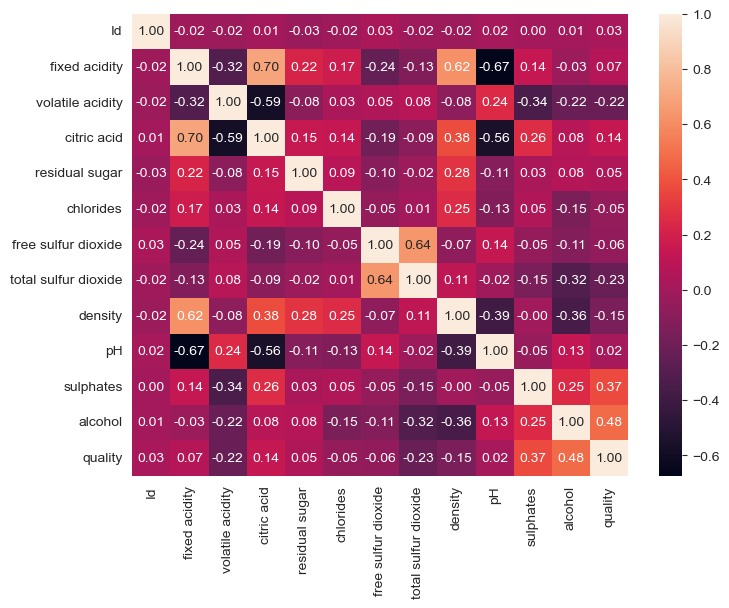

In [10]:
# 查看相關性
sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))
sns.heatmap(train.corr(), annot = True, fmt='.2f')

# 正相關
# citric acid vs fixed acidity 0.7 檸檬酸影響酸度
# total sulfur dioxide vs free sulfur dioxide 0.64 二氧化硫
# density vs fixed acidity 0.63 密度影響酸度
# quality vs alcohol 0.48 品質與酒精含量
# 負相關
# ph vs fixed acidity -0.67 酸度與 PH 值
# citric acid vs volatile acidity -0.59 酸度與揮發性酸
# volatile acidity vs quality -0.22 品質與揮發性酸
# total sulfur dioxide vs quality -0.23 品質與二氧化硫

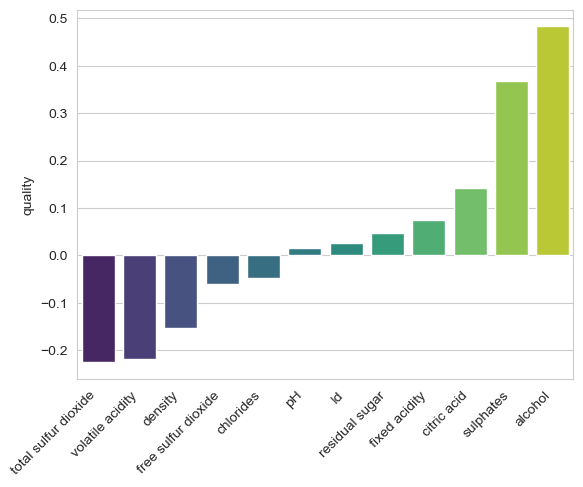

In [11]:
# 查看品質相關性
corr_q = train.corr()['quality'].sort_values()[:-1]
sns.barplot(corr_q, palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.show()

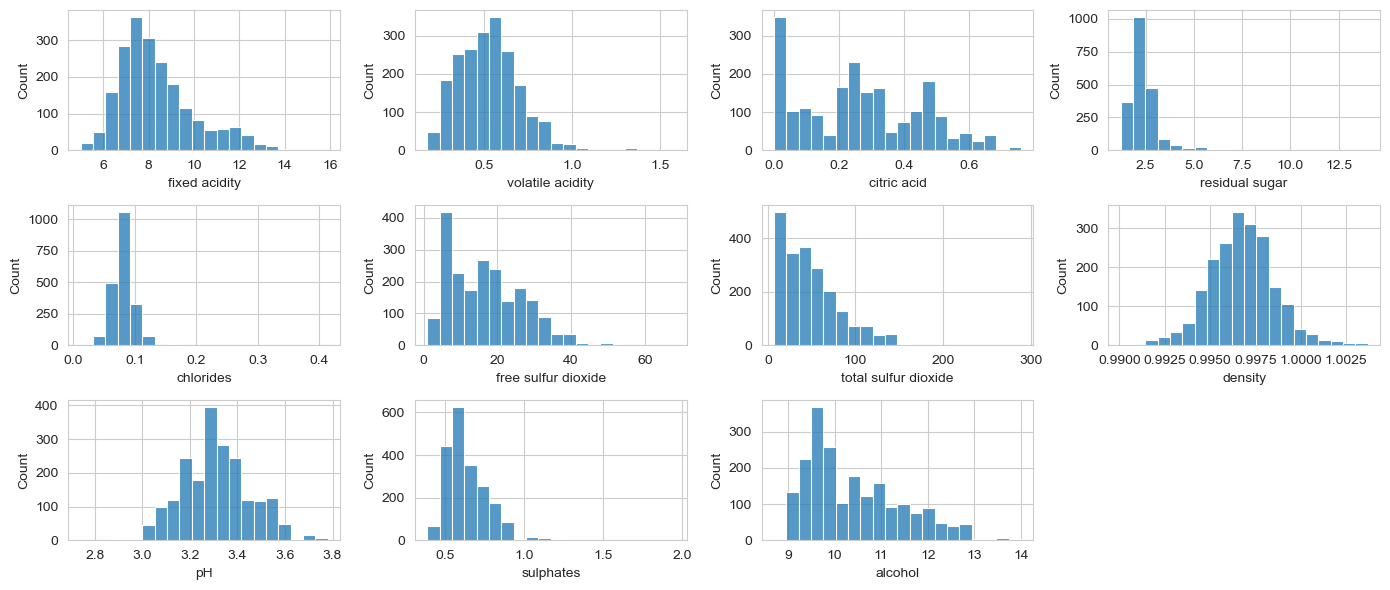

In [13]:
# 查看數值分布
plt.figure(figsize = (14, 6))
plt.subplot(3, 4, 1)
sns.histplot(train['fixed acidity'], bins = 20)

plt.subplot(3, 4, 2)
sns.histplot(train['volatile acidity'], bins = 20)

plt.subplot(3, 4, 3)
sns.histplot(train['citric acid'], bins = 20)

plt.subplot(3, 4, 4)
sns.histplot(train['residual sugar'], bins = 20)

plt.subplot(3, 4, 5)
sns.histplot(train['chlorides'], bins = 20)

plt.subplot(3, 4, 6)
sns.histplot(train['free sulfur dioxide'], bins = 20)

plt.subplot(3, 4, 7)
sns.histplot(train['total sulfur dioxide'], bins = 20)

plt.subplot(3, 4, 8)
sns.histplot(train['density'], bins = 20)

plt.subplot(3, 4, 9)
sns.histplot(train['pH'], bins = 20)

plt.subplot(3, 4, 10)
sns.histplot(train['sulphates'], bins = 20)

plt.subplot(3, 4, 11)
sns.histplot(train['alcohol'], bins = 20)

plt.tight_layout()
plt.show()

## Model

In [18]:
SEED = 42
NUM_FOLDS = 10

X = train.drop(['quality', 'Id'], axis = 1)
y = train['quality']

testing = test.drop('Id', axis = 1)

In [387]:
# 參數選擇
def objective_class(trial, train = X, target = y):
    
    le = LabelEncoder()

    # 使數據平衡平均分配
    kf = StratifiedKFold(n_splits=NUM_FOLDS, random_state=SEED, shuffle=True)
    
    params = {
        'random_state': SEED,
        'nthread': -1, 
        'objective': 'multi:softmax',
        'num_class': 10,
        
        'eta': trial.suggest_float('eta', 0, 1),
        'gamma': trial.suggest_float('gamma', 0, 20),  
        'max_depth': trial.suggest_int('max_depth', 0, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 0, 30), 
        'max_delta_step': trial.suggest_float('max_delta_step', 0, 30),
        'subsample': trial.suggest_float('subsample', 0, 1), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0, 1), 
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0, 2), 
        'lambda': trial.suggest_float('lambda', 0, 50), 
        'alpha': trial.suggest_float('alpha', 0, 50), 
     }
    
    scores = []
    
    for f, (train_idx, val_idx) in enumerate(kf.split(train, target)):
        
        train_df, val_df = train.iloc[train_idx], train.iloc[val_idx]
        train_target, val_target = target[train_idx], target[val_idx]
        
        
        y_train_code = le.fit_transform(train_target)
        y_test_code = le.fit_transform(val_target)

        trn_data = xgb.DMatrix(train_df, y_train_code)
        val_data = xgb.DMatrix(val_df, y_test_code)



        model = xgb.train(params, trn_data, num_boost_round=100,
                          evals=[(val_data, 'val_data')], verbose_eval=False, early_stopping_rounds=10)

        val_pred_data_class = model.predict(val_data)

        scores.append(accuracy_score(le.inverse_transform(val_pred_data_class.astype(int)), val_target))
        
    return np.mean(scores)

study = optuna.create_study(direction='maximize')
study.optimize(objective_class, n_trials = 50)

print('Best trial parameters:', study.best_params)
print('Best score:', study.best_value)

[I 2025-05-22 16:44:46,244] A new study created in memory with name: no-name-5717b81d-2436-42b1-9a0e-c7bee94b41e6
[I 2025-05-22 16:44:47,490] Trial 0 finished with value: 0.5350295998105612 and parameters: {'eta': 0.9883636873177069, 'gamma': 15.979026014911293, 'max_depth': 1, 'min_child_weight': 2, 'max_delta_step': 9.123635050045488, 'subsample': 0.6647351774924048, 'colsample_bytree': 0.5477732112346752, 'scale_pos_weight': 0.21500553811071232, 'lambda': 17.90189815235199, 'alpha': 22.753490602502346}. Best is trial 0 with value: 0.5350295998105612.
[I 2025-05-22 16:44:48,810] Trial 1 finished with value: 0.5413189675586076 and parameters: {'eta': 0.16417812455865455, 'gamma': 2.8291862842894755, 'max_depth': 10, 'min_child_weight': 26, 'max_delta_step': 12.467529878919128, 'subsample': 0.12331597403978711, 'colsample_bytree': 0.7645221345215173, 'scale_pos_weight': 1.7491188537779672, 'lambda': 0.2975568899419967, 'alpha': 36.49850090568744}. Best is trial 1 with value: 0.54131896

[I 2025-05-22 16:45:20,810] Trial 19 finished with value: 0.5612787118162443 and parameters: {'eta': 0.6914985534872802, 'gamma': 10.022795151655096, 'max_depth': 2, 'min_child_weight': 0, 'max_delta_step': 11.024310990913222, 'subsample': 0.8377914035920536, 'colsample_bytree': 0.20682139303578495, 'scale_pos_weight': 1.0260611976327205, 'lambda': 27.10450441460782, 'alpha': 49.698134452320076}. Best is trial 9 with value: 0.5865877338385034.
[I 2025-05-22 16:45:22,205] Trial 20 finished with value: 0.5768529481411317 and parameters: {'eta': 0.4472273269131116, 'gamma': 4.705634587424912, 'max_depth': 0, 'min_child_weight': 10, 'max_delta_step': 17.16272602563711, 'subsample': 0.4223943801433265, 'colsample_bytree': 0.6526914060885136, 'scale_pos_weight': 1.94664110101345, 'lambda': 46.80563639401947, 'alpha': 15.801753584021988}. Best is trial 9 with value: 0.5865877338385034.
[I 2025-05-22 16:45:23,581] Trial 21 finished with value: 0.5856121240824057 and parameters: {'eta': 0.52329

[I 2025-05-22 16:45:46,944] Trial 38 finished with value: 0.5233459625858394 and parameters: {'eta': 0.5945374182228036, 'gamma': 17.379488930843422, 'max_depth': 4, 'min_child_weight': 21, 'max_delta_step': 3.2396524961685267, 'subsample': 0.1743847690289848, 'colsample_bytree': 0.7007300656123207, 'scale_pos_weight': 1.9926744454250165, 'lambda': 47.27823473778009, 'alpha': 25.457925767732817}. Best is trial 23 with value: 0.5909685058015628.
[I 2025-05-22 16:45:48,166] Trial 39 finished with value: 0.5754155813402793 and parameters: {'eta': 0.9228006419992103, 'gamma': 3.214194424504937, 'max_depth': 5, 'min_child_weight': 15, 'max_delta_step': 1.061866587742816, 'subsample': 0.28069252754162816, 'colsample_bytree': 0.6165077092183475, 'scale_pos_weight': 1.4501352387898323, 'lambda': 39.72127533843044, 'alpha': 17.987350587979098}. Best is trial 23 with value: 0.5909685058015628.
[I 2025-05-22 16:45:49,269] Trial 40 finished with value: 0.5647051858868103 and parameters: {'eta': 0.

Best trial parameters: {'eta': 0.8279733156022024, 'gamma': 1.2805731324282872, 'max_depth': 1, 'min_child_weight': 2, 'max_delta_step': 4.227009567951404, 'subsample': 0.4663349745367772, 'colsample_bytree': 0.9957915520589915, 'scale_pos_weight': 1.137162567328994, 'lambda': 42.3663585395093, 'alpha': 7.956754150743961}
Best score: 0.5919441155576604


In [33]:
# 模型預測
def model_predict_class(train = X, target = y, test = testing):
    
    # 使數據平衡平均分配
    kf = StratifiedKFold(n_splits=NUM_FOLDS, random_state=SEED, shuffle=True)
    
    params = {
        'random_state': SEED,
        'nthread': -1, 
        'objective': 'multi:softmax',
        'num_class': 10,
        
        'eta': 0.8279733156022024, 
        'gamma': 1.2805731324282872, 
        'max_depth': 1, 'min_child_weight': 2, 
        'max_delta_step': 4.227009567951404, 
        'subsample': 0.4663349745367772, 
        'colsample_bytree': 0.9957915520589915, 
        'scale_pos_weight': 1.137162567328994, 
        'lambda': 42.3663585395093, 
        'alpha': 7.956754150743961
    }

    trn_data = xgb.DMatrix(train, label=target)
    test_data = xgb.DMatrix(test)

    model = xgb.train(params, trn_data, num_boost_round=100, verbose_eval=False)

    pred_data = model.predict(test_data)
        
    return pred_data

pred_data = model_predict_class()

array([6., 6., 5., ..., 5., 5., 5.], dtype=float32)

In [390]:
# 匯出 submission
sample_submission['quality'] = val_pred_data.round().astype(int)
sample_submission.to_csv('subsci_df_class.csv', index=False)
sample_submission

,Id,quality
0,2056,6
1,2057,6
2,2058,5
3,2059,6
4,2060,5
...,...,...
1367,3423,5
1368,3424,7
1369,3425,5
1370,3426,5


### 其他：使用 XGBClassifier

In [26]:
# XGBClassifier
def model_predict_classifier(train = X, target = y, test = testing):

    le = LabelEncoder()

    test_pred = 0
    scores = []


    kf = StratifiedKFold(n_splits=NUM_FOLDS, random_state=SEED, shuffle=True)

    for f, (train_idx, val_idx) in enumerate(kf.split(train, target)):

        X_train, X_test = train.iloc[train_idx], train.iloc[val_idx]
        y_train, y_test = target[train_idx], target[val_idx]

        y_train_code = le.fit_transform(y_train)
        y_test_code = le.fit_transform(y_test)

        xgb_clf = xgb.XGBClassifier(
            n_estimators = 500,
            learning_rate = 0.05,
            eval_metric = "mlogloss")

        xgb_clf.fit(X_train, y_train_code, verbose = False)

        pred_data = xgb_clf.predict(X_test)

        scores.append(accuracy_score(y_test, le.inverse_transform(pred_data)))

        test_pred += le.inverse_transform(xgb_clf.predict(test))/NUM_FOLDS

    return test_pred, np.mean(scores)

test_pred, scores = model_predict_classifier()

sample_submission['quality'] = test_pred.astype(int)
sample_submission.to_csv('subsci_df_classifier.csv', index=False)
sample_submission

test_pred :  [6.  6.4 6.  ... 5.2 5.  5.2]
scores :  0.5598413450153918


,Id,quality
0,2056,5
1,2057,6
2,2058,5
3,2059,5
4,2060,5
...,...,...
1367,3423,5
1368,3424,6
1369,3425,5
1370,3426,5


### 其他：使用 regression 

In [243]:
def objective_reg(trial, train = X, target = y):
    
    # 使數據平衡平均分配
    kf = StratifiedKFold(n_splits=num_folds, random_state=SEED, shuffle=True)
    
    params = {
        'eta': trial.suggest_float('eta', 0, 1),
        'gamma': trial.suggest_float('gamma', 0, 20), 
        'max_depth': trial.suggest_int('max_depth', 0, 10), 
        'min_child_weight': trial.suggest_int('min_child_weight', 0, 30), 
        'max_delta_step': trial.suggest_float('max_delta_step', 0, 30),
        'subsample': trial.suggest_float('subsample', 0, 1), 
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0, 1), 
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0, 2), 
        'lambda': trial.suggest_float('lambda', 0, 50), 
        'alpha': trial.suggest_float('alpha', 0, 50), 
     }
    
    scores = []
    
    for f, (train_idx, val_idx) in enumerate(kf.split(train, target)):
        
        train_df, val_df = train.iloc[train_idx], train.iloc[val_idx]
        train_target, val_target = target[train_idx], target[val_idx]

        trn_data = xgb.DMatrix(train_df, train_target)
        val_data = xgb.DMatrix(val_df, val_target)
        test_data = xgb.DMatrix(test)

        model = xgb.train(params, trn_data, num_boost_round=1000,
                          evals=[(val_data, 'val_data')], verbose_eval=False, early_stopping_rounds=10)

        val_pred_data = model.predict(val_data)
        
        
        scores.append(mean_squared_error(val_target, val_pred_data.round().astype('int')))
        
    return np.mean(scores)

study = optuna.create_study(direction='minimize')
study.optimize(objective_reg, n_trials = 50)

print('Best trial parameters:', study.best_params)
print('Best score:', study.best_value)


[I 2025-05-21 17:10:33,890] A new study created in memory with name: no-name-0429d7fa-0c21-4fde-8d09-ddb13d04bb3e
[I 2025-05-21 17:10:34,129] Trial 0 finished with value: 0.5725171678901255 and parameters: {'eta': 0.8095471019273717, 'gamma': 16.839521195672152, 'max_depth': 7, 'min_child_weight': 26, 'max_delta_step': 23.135009684290665, 'subsample': 0.8731608408459289, 'colsample_bytree': 0.6147258405724056, 'scale_pos_weight': 0.6326305570145407, 'lambda': 12.063739419053693, 'alpha': 22.153480086279163}. Best is trial 0 with value: 0.5725171678901255.
[I 2025-05-21 17:10:34,341] Trial 1 finished with value: 0.5579138053516457 and parameters: {'eta': 0.18670580970367767, 'gamma': 15.840590838251401, 'max_depth': 9, 'min_child_weight': 19, 'max_delta_step': 23.49288380625215, 'subsample': 0.5701910113078524, 'colsample_bytree': 0.5898212988933997, 'scale_pos_weight': 1.219034386443866, 'lambda': 46.17482626622085, 'alpha': 21.77885211702216}. Best is trial 1 with value: 0.55791380535

[I 2025-05-21 17:10:37,937] Trial 19 finished with value: 0.37840397821453936 and parameters: {'eta': 0.6359985423946504, 'gamma': 8.40713756961603, 'max_depth': 5, 'min_child_weight': 17, 'max_delta_step': 3.735147874206838, 'subsample': 0.0983684265841443, 'colsample_bytree': 0.3702566347534576, 'scale_pos_weight': 0.39301890342681567, 'lambda': 20.413396729684116, 'alpha': 39.344396904203414}. Best is trial 4 with value: 0.37840397821453936.
[I 2025-05-21 17:10:38,282] Trial 20 finished with value: 0.5798058252427184 and parameters: {'eta': 0.12716065828846645, 'gamma': 2.7452647232758136, 'max_depth': 4, 'min_child_weight': 8, 'max_delta_step': 13.54901933709669, 'subsample': 0.46909486985201865, 'colsample_bytree': 0.9964214422965489, 'scale_pos_weight': 1.813043301429017, 'lambda': 49.80769001174721, 'alpha': 5.962921478330635}. Best is trial 4 with value: 0.37840397821453936.
[I 2025-05-21 17:10:38,556] Trial 21 finished with value: 0.5510940089983423 and parameters: {'eta': 0.4

[I 2025-05-21 17:10:42,138] Trial 38 finished with value: 0.5798105612124083 and parameters: {'eta': 0.17208701755307107, 'gamma': 1.026107835159844, 'max_depth': 8, 'min_child_weight': 14, 'max_delta_step': 11.982913781186571, 'subsample': 0.6483515292885975, 'colsample_bytree': 0.6390337054792269, 'scale_pos_weight': 1.7291655301068052, 'lambda': 23.62707301717073, 'alpha': 17.39652801386248}. Best is trial 4 with value: 0.37840397821453936.
[I 2025-05-21 17:10:42,292] Trial 39 finished with value: 0.37840397821453936 and parameters: {'eta': 0.5852843539240669, 'gamma': 2.999141788392808, 'max_depth': 6, 'min_child_weight': 4, 'max_delta_step': 14.923181888690266, 'subsample': 0.14193494718450717, 'colsample_bytree': 0.18421803199310988, 'scale_pos_weight': 1.5471759296459617, 'lambda': 37.220480097890594, 'alpha': 41.814513204762044}. Best is trial 4 with value: 0.37840397821453936.
[I 2025-05-21 17:10:42,540] Trial 40 finished with value: 0.5700734075301916 and parameters: {'eta': 

Best trial parameters: {'eta': 0.40623781973319983, 'gamma': 6.0419986957095055, 'max_depth': 5, 'min_child_weight': 10, 'max_delta_step': 11.710459828187522, 'subsample': 0.14002301709572773, 'colsample_bytree': 0.46761357836748774, 'scale_pos_weight': 1.937822384427298, 'lambda': 31.268257820037277, 'alpha': 47.91599175107431}
Best score: 0.37840397821453936


In [43]:
def model_predict_reg(train = X, target = y, test = testing):
    
    test_pred = 0
    scores = []

    kf = StratifiedKFold(n_splits=NUM_FOLDS, random_state=SEED, shuffle=True)
    
    params = {
        'random_state': SEED,
        'objective': 'reg:squarederror',
        'nthread': -1, 
        
        'eta': 0.24383670805100566, 
        'gamma': 0.6148174565208251, 
        'max_depth': 5, 
        'min_child_weight': 12, 
        'max_delta_step': 2.1559070673491467, 
        'subsample': 0.8383847654915885, 
        'colsample_bytree': 0.6500674760300006, 
        'scale_pos_weight': 0.8647482462747366, 
        'lambda': 10.499277990812498, 
        'alpha': 24.532310710495764    
    }


    for f, (train_idx, val_idx) in enumerate(kf.split(train, target)):
        
        X_train, X_test = train.iloc[train_idx], train.iloc[val_idx]
        y_train, y_test = target[train_idx], target[val_idx]
        
        trn_data = xgb.DMatrix(X_train, label=y_train)
        val_data = xgb.DMatrix(X_test, label=y_test)
        test_data = xgb.DMatrix(test)

        model = xgb.train(params, trn_data, num_boost_round=100)

        val_pred_data = model.predict(val_data)

        scores.append(mean_squared_error(y_test, val_pred_data.round().astype('int')))
        
        pred_data = model.predict(test_data)

        test_pred += pred_data/NUM_FOLDS

    return test_pred, np.mean(scores)

test_pred, scores = model_predict_reg()

sample_submission['quality'] = test_pred.round().astype(int)
sample_submission.to_csv('subsci_df_reg.csv', index=False)
sample_submission

,Id,quality
0,2056,5
1,2057,6
2,2058,5
3,2059,6
4,2060,6
...,...,...
1367,3423,6
1368,3424,6
1369,3425,5
1370,3426,5
